# Intrinsic resolution of a Frankenstein model

When working with visibility fitting, the resulting image is not just a direct representation of the source. Instead, the reconstructed structure is inherently affected by the lack of data (incomplete sampling) in the $uv$-plane, the noise present in the observations, and the reconstruction quality of the algorithm itself.

To quantify the effective resolution of our model under these effects, we measure the **intrinsic resolution in the image plane** of the source.  Instead of relying solely on the theoretical size of a synthetic beam, we measure the actual smearing or broadening effect in the reconstructed image. The process consists of:

1. Taking a **radial cross-section** of the fitted structure (for example, a ring).
2. Fitting a **Gaussian profile** to that cross-section.
3. Extracting the **Full Width at Half Maximum (FWHM)** from the fit.

This is specified specifically detailed in Sierra et al. 2024, Appendix A (https://arxiv.org/abs/2408.15407).

### Why do we use this method?

Using the FWHM of the cross-section of the brightness profile of a ring is a robust metric for the following reasons:

* **UV-Sampling Effect:** It directly characterizes how the incomplete sampling of visibilities broadens fine structures.
* **Data Noise and Algorithm Bias:** It accounts for any extra "smoothing" or uncertainty introduced by the noise in the data and the specific fitting process of the algorithm.
* **Direct Comparison:** It provides a standardized metric to compare the resolution achieved by Frank2D directly with other traditional imaging algorithms, such as CLEAN.

This metric is essential for validating whether a structure (such as the width of a dust ring) is genuinely resolved, or if its observed size is dominated by observational and algorithmic limitations.

### Mathematical Relationship

The FWHM of a Gaussian profile is robustly related to its standard deviation ($\sigma$) as follows:

$$FWHM = 2\sqrt{2\ln 2} \sigma \approx 2.355 \sigma$$

#### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from frank2d import *
from frank.utilities import UVDataBinner

from scipy.special import j0
from scipy.optimize import curve_fit

#### Load data

In [2]:
dir = "../../data/uvtable/"
disk_name = "SimulatedBlob"
data_file = dir +"uvtable_SimulatedBlob.txt"

# Parameters for Geometry class, only for plotting purposes.
inc = 0
pa = 0
dra = 0
ddec = 0

rout = 1

# Load data
file = np.loadtxt(data_file, unpack =True)
u, v, Re, Im, Weights = file
Vis = Re + Im*1j
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

In [3]:
q = np.hypot(uvtable['u'], uvtable['v'])
Qmax = np.max(q)

Rmax = 3*rout
N = get_optimal_N(Rmax, Qmax)

print("N =", N)
print("Rmax =", Rmax)

N = 642
Rmax = 3


In [4]:
geom_f2d = Geometry(inc, pa, dra, ddec)

### FWHM of a $\delta$ Ring

When working with visibility fitting, the resulting image is not just a direct representation of the source. Instead, the reconstructed structure is inherently affected by the lack of data (incomplete uv-sampling), the noise present in the observations, and the reconstruction quality of the algorithm itself.

To quantify the effective resolution of our model, we measure the actual smearing in the reconstructed image. The process consists of:

1. Taking a **radial cross-section** of the fitted structure (for example, a ring).
2. Fitting a **Gaussian profile** to that cross-section.
3. Extracting the **Full Width at Half Maximum (FWHM)** from the fit.

As it is explained in Appendix A of Sierra et al. 2024 (https://arxiv.org/abs/2408.15407).

### Why do we use this method?

Using the FWHM of the cross-section is a robust metric for the following reasons:

* **UV-Sampling Effect:** It directly characterizes how the incomplete sampling of visibilities broadens fine structures.
* **Algorithm Bias:** Not all reconstruction algorithms recover information in the same way. This measurement accounts for any extra "smoothing" introduced by the fitting process.
* **Direct Comparison:** It allows us to compare the resolution achieved in the image directly with the physical scale of the source, making it easier to distinguish between a true feature of the object and a system limitation (the broadening).

> **Note:** This metric is essential for validating whether a structure (such as the width of a dust ring) is genuinely resolved, or if its observed size is dominated by the nature of the noise of the data, algorithm and lack of information.

### Mathematical Relationship

The FWHM of a Gaussian profile is related to its standard deviation ($\sigma$) as follows:

$$FWHM = 2\sqrt{2\ln 2} \sigma \approx 2.355 \sigma$$

In [5]:
du, dv, _ = geom_f2d.deproject(u, v)
dbaseline = np.hypot(du, dv)

baseline = np.hypot(u, v)

baseline_ring = baseline
u_ring = u
v_ring = v

Re_ring = np.median(Re[np.where(baseline_ring<5e4)])*np.real(j0(2.*np.pi*(Rmax/rad_to_arcsec/3.)*baseline_ring))
Imag_ring = np.zeros(len(Re))
Vis_ring = Re_ring + Imag_ring*1j

uvtable = {'u': u_ring, 'v': v_ring, 'vis': Vis_ring, 'weights': Weights}


In [6]:
frank2d = Frank2D(N, Rmax)
frank2d.process_vis(uvtable)

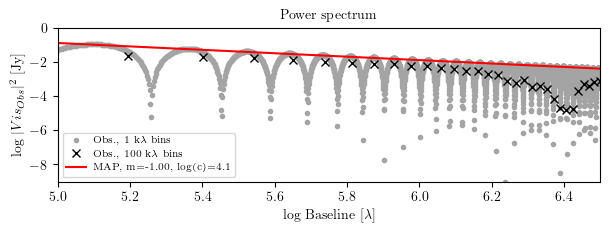

In [7]:
PlotRing = Plot(frank2d, geom_f2d)

m = -1
logp = -0.9
logq = 5
c = 10**(logp -  logq*m)
c

PlotRing.power_spectrum(uvtable, m = m, c =c)

In [8]:
frank2d.search_MAP(initial_guess={'m': m, 'logq': logq, 'logp': logp, "l": 1e4})

[WARNING] Using existing visibility data...


In [9]:
best = frank2d.MAP
best

{'m': np.float64(-0.5834704289104423),
 'c': np.float64(11.005751188092935),
 'l': np.float64(49245.657860787316)}

In [10]:
best = {'m': np.float64(-0.07521858832471538),
 'c': np.float64(0.05380025080241865),
 'l': np.float64(70656.63686048266)}


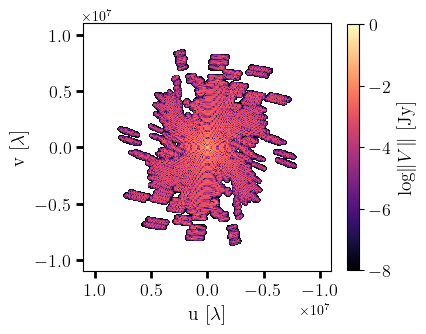

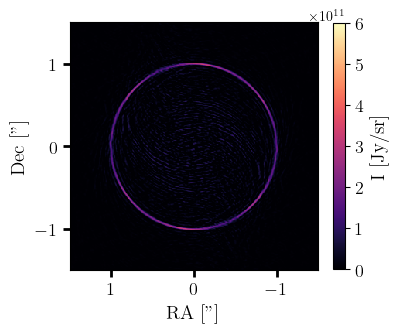

In [11]:
frank2d.fit( data = uvtable, kernel_params = {'m': best['m'], 'c': best['c'], 'l': best['l']})
PlotRing.visibility(fig_size = 4,  title= r'', vmax= 0, vmin= -8)
PlotRing.intensity(fig_size = 4, zoom=2, gamma =1, title = '', vmax =0.6e12)

FWHM= 0.022685675712731473 +/- 0.00020833084468345142 arcsec


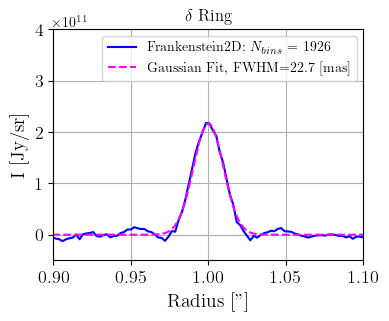

In [12]:
def gauss(r, sigma):
    return np.exp(-0.5*((r-Rmax/3.)/sigma)**2)


x_model_1d, y_model_1d = geom_f2d.deproject_xy(PlotRing._x_model_1d, PlotRing._y_model_1d)
x_model, y_model = PlotRing._x_model, PlotRing._y_model

I = frank2d.intensity_model

r_ = np.unique(np.hypot(x_model_1d, y_model_1d))
bins_f2d = 3*N
r = np.linspace(r_.min(), r_.max(), bins_f2d)
edges = PlotRing.edges(r)

r_f2d, I_f2d = PlotRing.get_profile(x_model, y_model, I, bins = edges)
I_f2d = np.nan_to_num(I_f2d, nan=0)

popt_frank2d, cov = curve_fit(gauss, r_f2d, I_f2d/np.max(I_f2d), p0=[0.09])
FWHM_frank2d = popt_frank2d[0]* 2. *np.sqrt(2.*np.log(2.))
Error_FWHM_f2d = np.sqrt(cov[0][0])* 2. *np.sqrt(2.*np.log(2.)) 

plt.close()
plt.figure(figsize=(4,3))
plt.plot(r_f2d, I_f2d, color='blue',label= r'Frankenstein2D: $N_{bins}$ = '+ str(bins_f2d))
plt.plot(r_f2d, gauss(r_f2d, *popt_frank2d)*np.max(I_f2d), ls = '--', color='magenta', label='Gaussian Fit, FWHM=%.1f [mas]'%(FWHM_frank2d*1000))
plt.ylabel(r'I [Jy/sr]', size=14)
plt.xlabel('Radius ["]', size=14)
plt.tick_params(axis='both', which='both', labelsize=13)
plt.xlim(0.9, 1.1)
plt.grid()
plt.ylim(-5e10, 0.4e12)

plt.title(r'$\delta$ Ring ')
plt.legend(loc='best', fontsize = 10)

print ('FWHM=', FWHM_frank2d, '+/-', Error_FWHM_f2d, 'arcsec')   

### We calculate the intrinsic resolution for Frankenstein as well
For this we use the full visibilities, not gridded.

In [13]:
u_f1d, v_f1d, Re_f1d, Imag_f1d, Weights_f1d = u, v, Re, Im, Weights
Vis_f1d = Re_f1d + Imag_f1d*1j

u_f1d_d, v_f1d_d, _ = geom_f2d.deproject(u_f1d, v_f1d)
dbaseline_f1d = np.hypot(u_f1d_d, v_f1d_d)
baseline_f1d = np.hypot(u_f1d, v_f1d)
baseline_ring_f1d = dbaseline_f1d

Re_ring = np.median(Re_f1d[np.where(baseline_ring_f1d<3e4)])*np.real(j0(2.*np.pi*(Rmax/rad_to_arcsec/3.)*baseline_ring_f1d))
Imag_ring = np.zeros(len(Re_ring))
Vis_f1d = Re_ring + Imag_ring*1j

uvtable_f1d = {'u': u_f1d, 'v': v_f1d, 'vis': Vis_f1d, 'weights': Weights_f1d}

In [14]:
# Frank 1D parameters
n_pts = N//2
alpha = 1.2
w_smooth = 1e-3

In [15]:
frank2d.frank1d(data = uvtable_f1d, rout = Rmax, n_pts = 2*n_pts, alpha = alpha, w_smooth = w_smooth, geom = geom_f2d)

In [16]:
sol_f1d = frank2d._sol_f1d
r_f1d = sol_f1d.r
I_f1d = sol_f1d.mean

In [17]:
popt_frank1d, cov_frank1d = curve_fit(gauss, r_f1d, I_f1d/np.max(I_f1d), p0=[0.02])
FWHM_frank1d = popt_frank1d[0]* 2. *np.sqrt(2.*np.log(2.))
Error_FWHM_frank1d = np.sqrt(cov_frank1d[0][0])* 2. *np.sqrt(2.*np.log(2.))

In [18]:
print ('FWHM=', FWHM_frank1d, '+/-', Error_FWHM_frank1d, 'arcsec')   

FWHM= 0.012999190340765234 +/- 0.00025120189735663344 arcsec


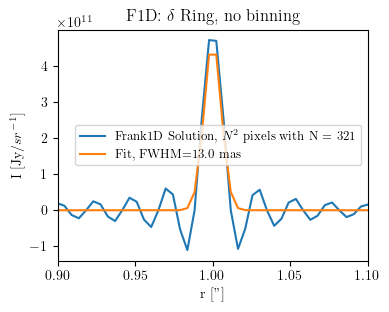

In [19]:
plt.close()
plt.figure(figsize=(4,3))
plt.plot(r_f1d, I_f1d, color='C0',label= r'Frank1D Solution, $N^{2}$ pixels with N = ' + str(n_pts))
plt.plot(r_f1d, gauss(r_f1d, *popt_frank1d)*np.max(sol_f1d.mean), color='C1', label='Fit, FWHM=%.1f mas'%(FWHM_frank1d*1000))
plt.ylabel(r'I [Jy/$sr^{-1}$]')
plt.xlabel('r ["]')
plt.xlim(0.9, 1.1)

plt.title(r'F1D: $\delta$ Ring, no binning')
plt.legend(loc='best', fontsize = 9)

Let's use this values in the 04_plot_class.ipynb

- FWHM_f2d = 22.7 mas
- FWHM_f1d = 13 mas